In [20]:
import sys
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.utils as vutils

In [9]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

device

device(type='mps')

In [10]:
cwd = Path.cwd()
project_root = cwd.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done")

In [11]:
from Scripts.utils import load_mnist_dataset

In [12]:
data_path = project_root / "data"
train_dataloader, test_dataloader = load_mnist_dataset(
    data_path=data_path,
    batch_size=128
)

In [13]:
next(iter(train_dataloader))

[tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         ...,
 
 
         [[[-1., -1., -1.,  ..., -

### Dataset is ready, Let's build the generator

In [14]:
class Generator(nn.Module):
    def __init__(self, noise_size: int):
        super().__init__()

        self.leaky_relu = nn.LeakyReLU()
        self.layer1 = nn.ConvTranspose2d(in_channels=noise_size, out_channels=256, stride=1, padding=0, kernel_size=7)
        self.batch_norm_1 = nn.BatchNorm2d(256)
        self.layer2 = nn.ConvTranspose2d(in_channels=256, out_channels=128, stride=2, padding=1, kernel_size=4)
        self.batch_norm_2 = nn.BatchNorm2d(128)
        self.layer3 = nn.ConvTranspose2d(in_channels=128, out_channels=1, stride=2, padding=1, kernel_size=4)
        self.tanh = nn.Tanh()

    def forward(self, X):
        X = self.layer1(X)          # (128, 256, 7, 7)
        X = self.batch_norm_1(X)    # (128, 256, 7, 7)
        X = self.leaky_relu(X)      # (128, 256, 7, 7)
        X = self.layer2(X)          # (128, 128, 14, 14)
        X = self.batch_norm_2(X)    # (128, 128, 14, 14)
        X = self.leaky_relu(X)      # (128, 128, 14, 14)
        X = self.layer3(X)          # (128, 1, 28, 28)
        X = self.tanh(X)            # (128, 1, 28, 28)

        return X

In [15]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.leaky_relu = nn.LeakyReLU(negative_slope=0.2)
        self.layer1 = nn.Conv2d(in_channels=1, out_channels=128, stride=2, padding=1, kernel_size=4)
        self.layer2 = nn.Conv2d(in_channels=128, out_channels=256, stride=2, padding=1, kernel_size=4)
        self.layer3 = nn.Conv2d(in_channels=256, out_channels=1, stride=1, padding=0, kernel_size=7)

    def forward(self, X):
        X = self.layer1(X)      # (128, 128, 14, 14)
        X = self.leaky_relu(X)  # (128, 128, 14, 14)
        X = self.layer2(X)      # (128, 256, 7, 7)
        X = self.leaky_relu(X)  # (128, 256, 7, 7)
        X = self.layer3(X)      # (128, 1, 1, 1)

        return X.view(-1, 1)

### Let's create a visualization function

In [21]:
def visualize_generated_digits(generator, noise_dim, device, num_images=16):
    """Generates and displays a grid of images from the current generator state."""
    
    # 1. Set generator to evaluation mode (disables dropout, fixes batchnorm stats)
    generator.eval()
    
    # 2. Generate images without tracking gradients (saves memory/compute)
    with torch.no_grad():
        # Create fresh noise
        noise = torch.randn(num_images, noise_dim, 1, 1, device=device)
        # Generate raw fake images
        fake_images = generator(noise)
        
    # 3. Un-normalize the images from [-1, 1] back to [0, 1]
    fake_images = (fake_images + 1) / 2.0
    
    # 4. Arrange the batch of images into a single grid image
    # nrow=4 means a 4x4 grid for 16 images
    grid = vutils.make_grid(fake_images, nrow=4, padding=2, normalize=False)
    
    # 5. Convert to numpy, move to CPU, and rearrange dimensions for matplotlib
    # PyTorch is (C, H, W) -> Matplotlib needs (H, W, C)
    grid_np = grid.cpu().numpy().transpose((1, 2, 0))
    
    # 6. Plot the grid
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title("WGAN Generated Digits")
    # cmap='gray' is required otherwise matplotlib tries to add artificial colors to 1-channel images
    plt.imshow(grid_np, cmap='gray') 
    plt.show()
    
    # 7. Crucial: Put the generator back into training mode!
    generator.train()

### Generator and Critic are ready, Let's Initialize

In [18]:
# Hyperparameters
LEARNING_RATE = 5e-5
NOISE_DIM = 100
BATCH_SIZE = 128
CLIP_VALUE = 0.01
CRITIC_ITERATIONS = 5

# INITIALIZING THE GENERATOR AND THE DISCRIMINATOR
generator = Generator(noise_size=NOISE_DIM).to(device=device)
critic = Critic().to(device=device)

# Initializing the optimizers
opt_gen = optim.RMSprop(params=generator.parameters(), lr=LEARNING_RATE)
opt_crit = optim.RMSprop(params=critic.parameters(), lr=LEARNING_RATE)

In [22]:
def train(
        device,
        noise_dim: int,
        batch_size: int,
        clip_value: int,
        critic_iterations: int,
        generator: Generator,
        critic: Critic,
        opt_gen: optim.RMSprop,
        opt_crit: optim.RMSprop,
        dataloader,
        epochs: int = 3,
):
    for epoch in range(epochs):
        total_generator_loss = 0.0
        total_critic_loss = 0.0
        for batch, _ in dataloader:
            batch = batch.to(device)
            batch_critic_loss = 0.0
            for _ in range(critic_iterations):
                noise = torch.randn(size=[batch_size, noise_dim, 1, 1], device=device)
                fake_images = generator.forward(noise)
                critic_real = critic.forward(batch)
                critic_fake = critic.forward(fake_images.detach())
                critic_loss = -(torch.mean(critic_real) - torch.mean(critic_fake))
                batch_critic_loss += critic_loss.item()

                # backward
                opt_crit.zero_grad()
                critic_loss.backward()
                opt_crit.step()

                # cliping
                for p in critic.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            
            total_critic_loss += batch_critic_loss/critic_iterations

            new_noise = torch.randn(size=[batch_size, noise_dim, 1, 1], device=device)
            new_fake_images = generator.forward(new_noise)
            critic_score = critic.forward(new_fake_images)
            generator_loss = -torch.mean(critic_score)
            total_generator_loss += generator_loss.item()

            # backward
            opt_gen.zero_grad()
            generator_loss.backward()
            opt_gen.step()
        
        avg_gen_loss = total_generator_loss / len(dataloader)
        avg_crit_loss = total_critic_loss / len(dataloader)
        print(f"Epoch: ({epoch+1}/{epochs}) | Avg Gen Loss: {avg_gen_loss:.4f} | Avg Critic Loss: {avg_crit_loss:.4f}")

        # visualize
        visualize_generated_digits(generator, noise_dim, device)

    return generator, critic

## Let's see it train

Epoch: (1/4) | Avg Gen Loss: -0.1646 | Avg Critic Loss: -34.0397


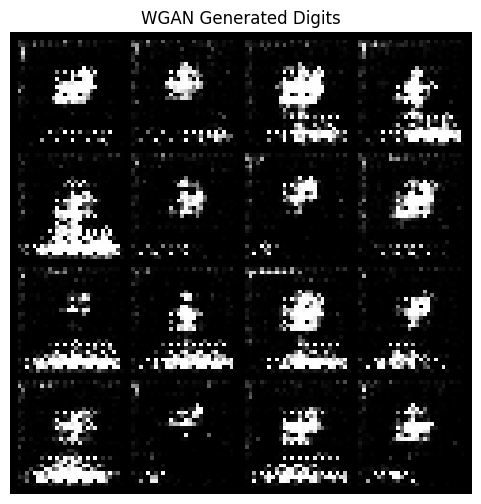

Epoch: (2/4) | Avg Gen Loss: -5.0654 | Avg Critic Loss: -0.6400


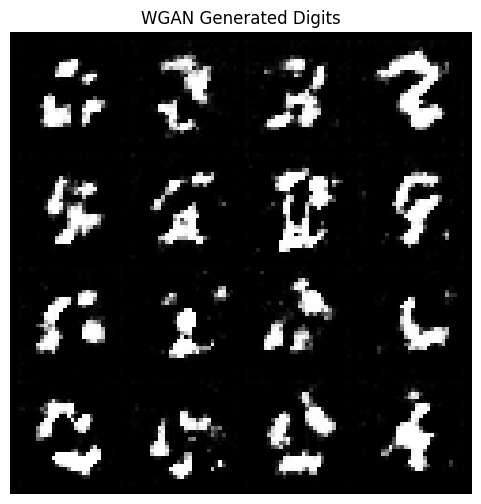

KeyboardInterrupt: 

In [23]:
trained_generator, trained_critic = train(
    device=device,
    noise_dim=NOISE_DIM,
    batch_size=BATCH_SIZE,
    clip_value=CLIP_VALUE,
    critic_iterations=CRITIC_ITERATIONS,
    generator=generator,
    critic=critic,
    opt_gen=opt_gen,
    opt_crit=opt_crit,
    dataloader=train_dataloader,
    epochs=4
)